# Agentic Architectures — Analysis Notebook

**Runnable experiment deliverable.** Loads both domains' result files, builds the
4×4 capability/efficiency matrices, classifies failures, evaluates each
hypothesis, and renders every figure used in the report. All heavy lifting is in
`src.analysis`, so this notebook stays thin and cannot drift from the CLI
(`scripts/analyze_results.py`), which calls the same functions.

**How to run it:** point `LOGIC_PATH` / `GRIDWORLD_PATH` at the two JSONL result
files and run all cells top to bottom. Each section closes with a short
**interpretation** of what the numbers say, and the per-hypothesis verdicts
(H1–H5) are read off the tables and figures rather than asserted in prose alone.

In [1]:
%load_ext autoreload 
%autoreload 2

In [2]:
import sys, os
# Make `src` importable when the notebook lives in notebooks/.
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("."))

import pandas as pd
import matplotlib.pyplot as plt

from src.analysis import load_all, add_failure_mode, LEVEL_ORDER, ARCH_ORDER
from src.analysis import aggregate as agg
from src.analysis import plots

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

## 0. Load your results

Set the two paths to the uploaded JSONL files and run.

In [3]:
# Edit these two paths to point at your result files.
LOGIC_PATH     = "../results/logic_final.jsonl"
GRIDWORLD_PATH = "../results/gridworld_final.jsonl"

df = add_failure_mode(load_all(LOGIC_PATH, GRIDWORLD_PATH))
assert not df.empty, (
    "No rows loaded. Check LOGIC_PATH / GRIDWORLD_PATH point at the uploaded "
    "JSONL files (e.g. results/logic_final.jsonl)."
)
print(f"Loaded {len(df)} runs across {df['domain'].nunique()} domain(s): "
      f"{sorted(df['domain'].unique())}")
df.head(3)

Loaded 1044 runs across 2 domain(s): ['gridworld', 'logic_puzzles']


/home/kneme/projects/nlp-fm-agentic-project/src/analysis/loader.py:157: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(frames, ignore_index=True)


,domain,architecture,difficulty,level,thinking_token_budget,task_id,run_id,max_critic_iterations,success,score,total_tokens,prompt_tokens,completion_tokens,num_llm_calls,max_per_call_completion,runtime_seconds,parse_failure,any_call_truncated,budget_saturated,revision_count,error,num_steps,reached_goal,correct_cells,total_cells,puzzle_id,answer_schema,branch_count,mem_retrievals,mem_reuse_hits,final_answer,failure_mode,is_capability
0,logic_puzzles,level1,easy,easy,NaN,0,0,3,True,1.0,14133,377,13756,1,13756,218.974,False,False,False,0,None,None,None,9.0,9.0,Pt2_3x3_level3-0,attribute_dict,NaN,NaN,NaN,"\n\n{""Food"": [""potato"", ""peach"", ""avocado""], ""...",success,True
1,logic_puzzles,level1,easy,easy,NaN,0,2,3,True,1.0,14463,377,14086,1,14086,4155.137,False,False,False,0,None,None,None,9.0,9.0,Pt2_3x3_level3-0,attribute_dict,NaN,NaN,NaN,"\n\n{""Food"": [""potato"", ""peach"", ""avocado""], ""...",success,True
2,logic_puzzles,level1,easy,easy,NaN,0,1,3,True,1.0,19751,377,19374,1,19374,312.426,False,False,False,0,None,None,None,9.0,9.0,Pt2_3x3_level3-0,attribute_dict,NaN,NaN,NaN,"\n\n{\n ""Food"": [""potato"", ""peach"", ""avocado""...",success,True


## 1. Matrix coverage

Before interpreting anything, check which (architecture × difficulty) cells actually have runs.

In [4]:
agg.coverage_report(df)

,domain,architecture,level,n_runs
0,gridworld,level1,easy,40
1,gridworld,level1,medium,40
2,gridworld,level1,hard,40
3,gridworld,level1,extra_hard,50
4,gridworld,level2a,easy,40
5,gridworld,level2a,medium,40
6,gridworld,level2a,hard,40
7,gridworld,level2a,extra_hard,50
8,gridworld,level2b,easy,40
9,gridworld,level2b,medium,40


**Interpretation.** Two things to carry into everything below.

*The capability subset shrinks at tight budgets.* This table counts **all** runs,
but the capability mean later drops truncated and errored runs. That gap is large
for L3 at the hardest levels — logic L3 `extra_hard` has 40 runs but only ≈4
survive into the capability mean (the rest are truncated), and gridworld L3 loses
26–78% of runs to truncation depending on level.

## 2. Capability matrices — our primary metric

Capability is the **mean cell-level score** (0–1) per (architecture, difficulty),
with a percentile bootstrap 95% confidence interval. It is averaged only over
capability-eligible runs: runs that errored on the endpoint (`infra_error`) or
had their output clipped by the token limit (`truncated`) are **excluded**,
because a clipped run reflects the budget margin rather than the architecture's
reasoning. Success rate (fraction of perfectly solved instances) is shown
alongside but is only the secondary metric — it throws away the partial-credit
information that matters most at tight budgets.

In [5]:
cap_logic = agg.capability_matrix_with_ci(df, "logic_puzzles")
cap_grid  = agg.capability_matrix_with_ci(df, "gridworld")
display(cap_logic)
display(cap_grid)

,architecture,level,n,mean_score,ci_lo,ci_hi,success_rate
0,level1,easy,9,1.000000,1.000000,1.000000,1.000000
1,level1,medium,12,1.000000,1.000000,1.000000,1.000000
2,level1,hard,30,0.844000,0.781333,0.904000,0.433333
3,level1,extra_hard,39,0.496410,0.437949,0.555897,0.000000
4,level2a,easy,9,1.000000,1.000000,1.000000,1.000000
5,level2a,medium,12,1.000000,1.000000,1.000000,1.000000
6,level2a,hard,25,0.913600,0.844800,0.971200,0.760000
7,level2a,extra_hard,18,0.773333,0.628889,0.904444,0.611111
8,level2b,easy,9,1.000000,1.000000,1.000000,1.000000
9,level2b,medium,12,1.000000,1.000000,1.000000,1.000000


,architecture,level,n,mean_score,ci_lo,ci_hi,success_rate
0,level1,easy,40,1.000000,1.000000,1.000000,1.000000
1,level1,medium,40,1.000000,1.000000,1.000000,1.000000
2,level1,hard,39,0.961310,0.898581,1.000000,0.948718
3,level1,extra_hard,50,0.805536,0.708571,0.895719,0.740000
4,level2a,easy,40,0.982500,0.947500,1.000000,0.975000
5,level2a,medium,40,1.000000,1.000000,1.000000,1.000000
6,level2a,hard,39,0.937042,0.874084,0.985577,0.897436
7,level2a,extra_hard,42,0.694940,0.572704,0.813988,0.619048
8,level2b,easy,39,1.000000,1.000000,1.000000,1.000000
9,level2b,medium,40,0.982143,0.946429,1.000000,0.975000


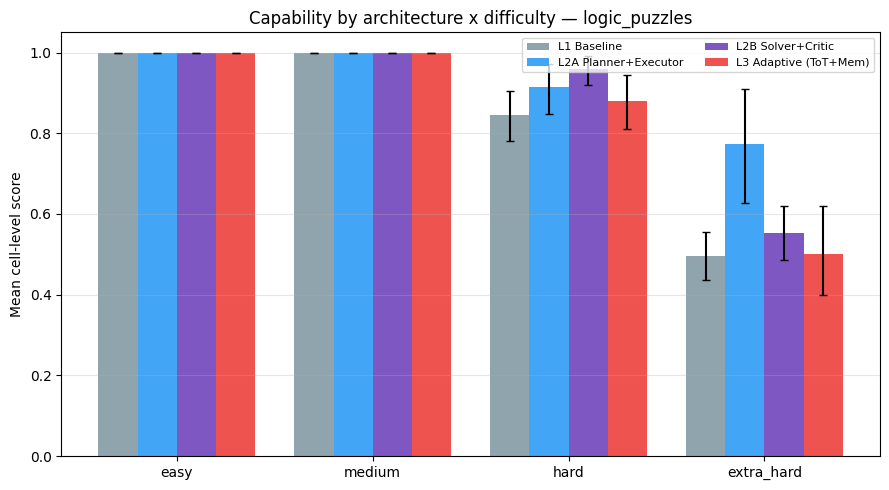

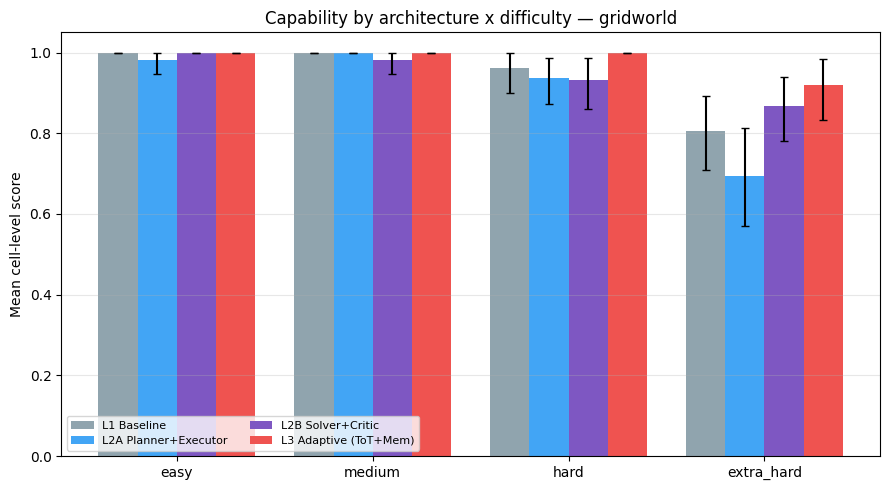

In [6]:
plots.plot_capability(df, "logic_puzzles"); plt.show()
plots.plot_capability(df, "gridworld"); plt.show()

**Interpretation.** `easy` and `medium` sit at ceiling (≈1.0) for every
architecture in both domains — they don't separate the designs. The signal is at
`hard`/`extra_hard`:

- **Logic:** added structure helps. At `extra_hard`, L2A (0.77) and L2B (0.55)
  both beat the L1 baseline (0.50), and the planner (L2A) is strongest. L3's
  `extra_hard` cell (0.50) looks weak but rests on ≈4 eligible runs, so read it
  with the CI, not at face value.
- **Gridworld:** the ordering flips. L3 is the most capable at the top
  (1.0 at `hard`, 0.92 at `extra_hard`) while the planner-first L2A is the
  *weakest* there (0.69). The reflective architectures (L2B, L3) hold up best
  under fog and tight budgets.

The headline is already visible: explicit planning helps on the static domain and
hurts on the dynamic one (H3).

## 3. Efficiency — tokens and call counts

`total_tokens` is the real compute cost; `num_llm_calls` (the number of model
turns) is the architecture-level overhead. Both keep every run that produced
token counts, including truncated ones — truncation is part of the cost story.
Runtime is logged but not interpreted, as wall-clock time fluctuated intensely
with a fixed token budget.

--- logic_puzzles: total_tokens ---


level,easy,medium,hard,extra_hard
architecture,,,,
level1,11687.777778,13357.583333,4844.133333,2400.60
level2a,21794.000000,19814.083333,11086.333333,7465.30
level2b,13719.333333,17529.000000,15369.266667,13028.55
level3,41866.666667,59522.333333,27002.900000,15410.60


--- logic_puzzles: num_llm_calls ---


level,easy,medium,hard,extra_hard
architecture,,,,
level1,1.0,1.0,1.000000,1.00
level2a,2.0,2.0,2.000000,2.00
level2b,2.0,2.0,2.933333,3.95
level3,5.0,5.0,5.000000,5.00


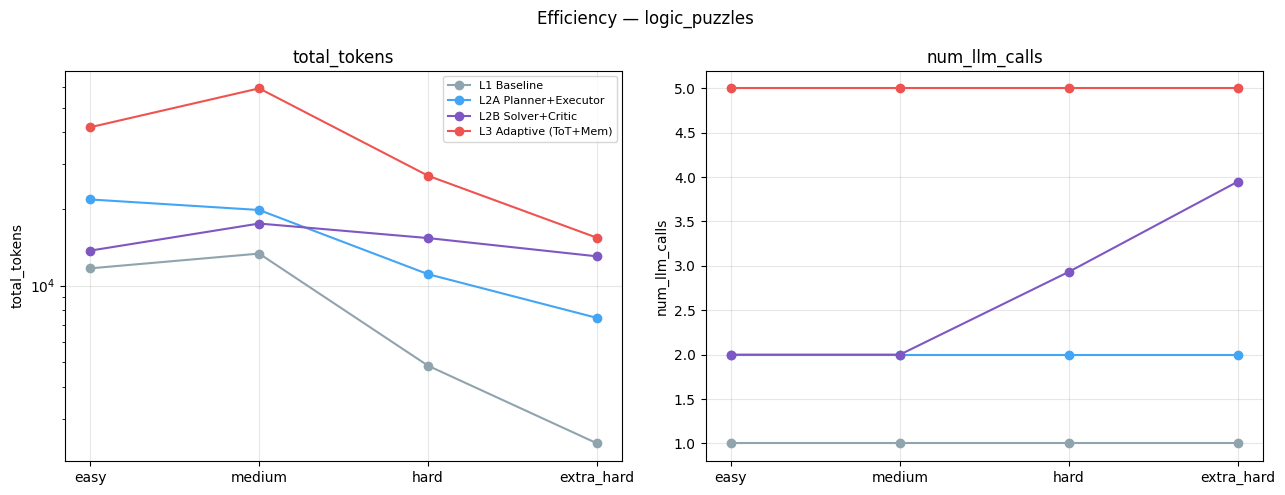

--- gridworld: total_tokens ---


level,easy,medium,hard,extra_hard
architecture,,,,
level1,8865.925,15908.150,17527.725,17921.52
level2a,13947.925,19304.800,29545.375,23602.78
level2b,11502.700,18553.625,21315.650,19646.76
level3,130946.250,120474.150,97741.575,40338.94


--- gridworld: num_llm_calls ---


level,easy,medium,hard,extra_hard
architecture,,,,
level1,6.500,9.175,9.625,10.34
level2a,7.475,8.800,11.575,10.96
level2b,7.400,10.325,12.225,11.68
level3,10.200,12.475,12.925,17.74


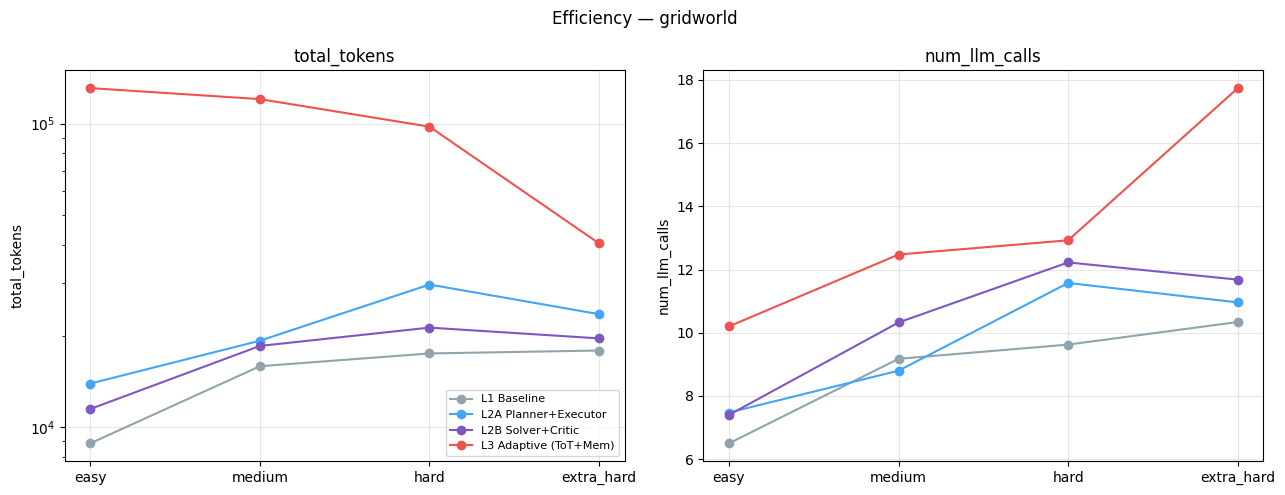

In [7]:
for dom in ["logic_puzzles", "gridworld"]:
    print(f"--- {dom}: total_tokens ---");      display(agg.efficiency_matrix(df, dom, "total_tokens"))
    print(f"--- {dom}: num_llm_calls ---");     display(agg.efficiency_matrix(df, dom, "num_llm_calls"))
    plots.plot_efficiency_pair(df, dom); plt.show()

**Interpretation.** Cost rises with architectural complexity, and **L3 is by far
the most expensive everywhere** — in gridworld it spends ≈130k tokens per easy run
versus ≈9k for L1 (over 10×), because every run fans out into 3 planner branches
and may loop through the critic. The **call-count ladder** is the clean structural
truth: in logic L1 = 1, L2A = 2, L2B ≈ 2–4 (rising as the critic loops on `hard`),
L3 = 5. In gridworld the counts are larger and noisier for *every* architecture,
because the executor is a tool-calling loop whose length depends on the trajectory
— so gridworld `num_llm_calls` mixes model turns with environment steps.

## 4. Hypothesis-by-hypothesis

Each hypothesis maps to a specific slice of the data. Verdicts are read off the
tables and figures (SUPPORTED / PARTIAL / REFUTED).

### H1 — more complexity → higher cost, with L3 most expensive everywhere

Read this one off the efficiency tables and figure in §3.

- **L3 is the most expensive architecture in every cell**, by a wide margin in
  tokens (≈10–15× L1 in gridworld). This part of H1 is **supported**.
- The **call-count ladder** L1 = 1 < L2A = 2 < L2B (variable, 2–4) < L3 = 5 is the
  clean structural ordering — clearest in logic, where calls are pure model turns.
- Token cost is **not** strictly monotone across L2A → L2B at easy/medium, so the
  monotonic form of H1 is only **partially supported**: complexity raises cost in
  general and L3 dominates, but the L2A/L2B order swaps when the critic stays idle.


### H2 — linear pipelines have tight call counts; cyclic ones are high-variance

Each dot is one run. The dots for a given
architecture are split into four difficulty sub-columns (colour = difficulty), and
the black tick marks each condition's mean. So a pile of dots is simply the
repeated runs of one (architecture, difficulty) condition — that within-condition
spread is the quantity H2 is about. A tight vertical cluster ⇒ a near-deterministic
call count; a tall spread ⇒ the architecture loops a variable number of times.

--- logic_puzzles ---


,architecture,level,mean,std,count,cv
4,level2a,easy,2.000000,0.000000,9,0.000000
5,level2a,medium,2.000000,0.000000,12,0.000000
6,level2a,hard,2.000000,0.000000,30,0.000000
7,level2a,extra_hard,2.000000,0.000000,40,0.000000
8,level2b,easy,2.000000,0.000000,9,0.000000
9,level2b,medium,2.000000,0.000000,12,0.000000
10,level2b,hard,2.933333,1.014833,30,0.345966
11,level2b,extra_hard,3.950000,0.316228,40,0.080058


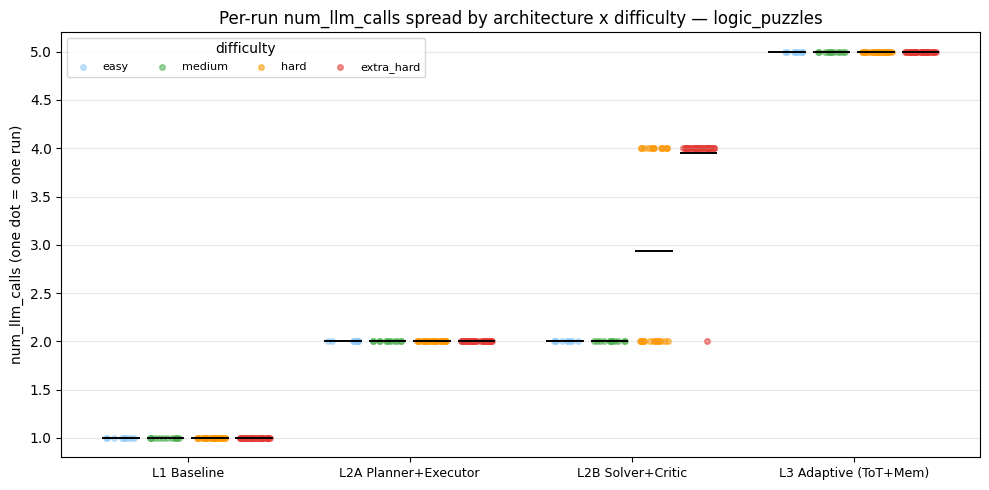

--- gridworld ---


,architecture,level,mean,std,count,cv
4,level2a,easy,7.475,0.715667,40,0.095741
5,level2a,medium,8.800,3.267556,40,0.371313
6,level2a,hard,11.575,3.128754,40,0.270303
7,level2a,extra_hard,10.960,3.181323,50,0.290267
8,level2b,easy,7.400,1.032796,40,0.139567
9,level2b,medium,10.325,2.535770,40,0.245595
10,level2b,hard,12.225,3.964506,40,0.324295
11,level2b,extra_hard,11.680,3.106543,50,0.265971


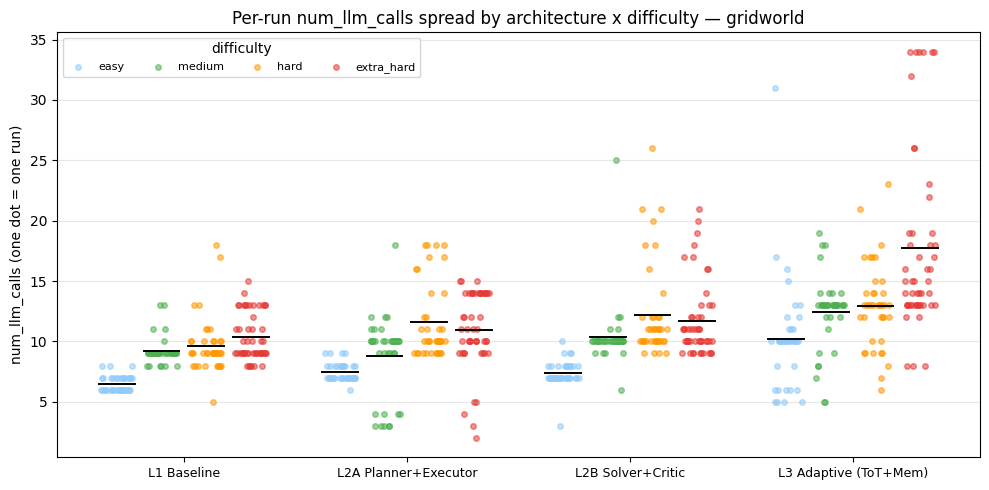

In [8]:
for dom in ["logic_puzzles", "gridworld"]:
    disp = agg.dispersion_table(df, dom, "num_llm_calls")
    print(f"--- {dom} ---")
    display(disp[disp["architecture"].isin(["level2a", "level2b"])])
    plots.plot_dispersion(df, dom, "num_llm_calls"); plt.show()

**Interpretation. Domain-dependent — partially supported.**

- **Logic (call count = model turns only):** clean support. L2A's CV is exactly 0
  (always 2 calls); L2B's CV is 0 at easy/medium and jumps on `hard` (CV ≈ 0.35) as
  the critic rejects and loops. Precisely the "linear = tight, cyclic = spread"
  prediction.
- **Gridworld (call count includes the tool loop):** the prediction blurs. Both
  L2A and L2B show substantial CV (≈0.1–0.37), because the ReAct executor takes a
  trajectory-dependent number of steps, so even the "linear" pipeline is not
  fixed-call.

### H3 — explicit planning helps on the static domain, hurts on the dynamic one
Planner advantage = mean(L2A) − mean(L1) per (domain, level), over
capability-eligible runs. Positive ⇒ the up-front plan helps; negative ⇒ it hurts.

In [ ]:
display(agg.planner_advantage(df))

,domain,level,score_level1,score_level2a,score_level2b,adv_vs_l1,adv_vs_l2b
0,gridworld,easy,1.000000,0.982500,1.000000,-0.017500,-0.017500
1,gridworld,medium,1.000000,1.000000,0.982143,0.000000,0.017857
2,gridworld,hard,0.961310,0.937042,0.932143,-0.024267,0.004899
3,gridworld,extra_hard,0.805536,0.694940,0.867143,-0.110595,-0.172202
4,logic_puzzles,easy,1.000000,1.000000,1.000000,0.000000,0.000000
5,logic_puzzles,medium,1.000000,1.000000,1.000000,0.000000,0.000000
6,logic_puzzles,hard,0.844000,0.913600,0.958621,0.069600,-0.045021
7,logic_puzzles,extra_hard,0.496410,0.773333,0.552821,0.276923,0.220513


**Interpretation. Supported — this is the headline cross-domain result.** The sign
of the planner advantage flips with the domain and grows with difficulty:

- **Logic (static):** advantage is **positive and grows** — +0.07 at `hard`,
  **+0.28** at `extra_hard`. Committing to a plan before solving helps when the
  problem is fully specified up front.
- **Gridworld (dynamic):** advantage is **negative and worsens** — −0.02 at
  `hard`, **−0.11** at `extra_hard`. A plan formed before the maze is observed
  (and, under fog, before the walls are even visible) breaks on contact, so the
  planner trails the reactive baseline.

### H4 — the critic hurts at low complexity, but adaptivity pays off at the top
gap = mean(L3) − (best mean among L1/L2A/L2B), per (domain, level).

For each (domain, level) we take L3's
mean cell-score and subtract the **best architecture mean** among the three
simpler systems — i.e. "does adding adaptivity beat the *strongest simpler
alternative* here?". The bar is the best architecture **average**, not the best
single run.

In [ ]:
gap = agg.l3_gap_vs_best(df)
display(gap if not gap.empty else "no L3 rows yet")

,domain,level,l3_mean,l3_n,best_other_arch,best_other_mean,gap
0,gridworld,easy,1.000000,9,level1,1.000000,0.000000
1,gridworld,medium,1.000000,16,level1,1.000000,0.000000
2,gridworld,hard,1.000000,19,level1,0.961310,0.038690
3,gridworld,extra_hard,0.918436,37,level2b,0.867143,0.051293
4,logic_puzzles,easy,1.000000,9,level1,1.000000,0.000000
5,logic_puzzles,medium,1.000000,11,level1,1.000000,0.000000
6,logic_puzzles,hard,0.880000,25,level2b,0.958621,-0.078621
7,logic_puzzles,extra_hard,0.500000,4,level2a,0.773333,-0.273333


**Interpretation. Domain-split — supported on gridworld, refuted on logic.**

- **Gridworld:** matches the prediction. Gap is 0 at easy/medium (L3 ties the
  ceiling), then **positive where it counts** — +0.04 at `hard`, +0.05 at
  `extra_hard` — so the adaptive system is the single best architecture under fog
  and tight budgets.
- **Logic:** prediction **fails**. Gap is 0 at easy/medium but **negative** at
  `hard` (−0.08) and `extra_hard` (−0.27); the planner-only L2A is the logic
  winner. Caveat: logic `extra_hard` has only `l3_n` ≈ 4 eligible runs (90%
  truncated), so that −0.27 is noisy — but L3 already trails at `hard` (n ≈ 25),
  so the shortfall isn't only small-N.

Consistent with H3: on the static domain one good plan (L2A) suffices and the extra
critic/branching machinery mostly adds cost and over-correction; on the dynamic
domain that same machinery is what survives.

### H5 — memory and branching: reported descriptively, not as a causal test
Per (domain, level) averages of
`branch_count` (ToT branches generated), `mem_retrievals` (past episodes pulled
into the planner prompt), and `mem_reuse_hits` (retrieved hints that actually
survived into the chosen plan).

**Why descriptive only.** There is no L3-without-memory ablation, so we cannot
attribute any score or efficiency difference to memory specifically — these counts
show *how much* the mechanisms fire, not their causal effect. Read them as
evidence, not proof (the ablation is declared future work).

In [11]:
diag = agg.l3_memory_diagnostics(df)
display(diag if not diag.empty else "no L3 rows yet")

,domain,level,branch_count,mem_retrievals,mem_reuse_hits
0,gridworld,easy,3.0,1.925000,0.925000
1,gridworld,medium,3.0,1.925000,1.225000
2,gridworld,hard,3.0,1.925000,0.950000
3,gridworld,extra_hard,3.0,1.940000,0.440000
4,logic_puzzles,easy,3.0,1.666667,0.111111
5,logic_puzzles,medium,3.0,1.750000,0.000000
6,logic_puzzles,hard,3.0,1.900000,0.000000
7,logic_puzzles,extra_hard,3.0,1.925000,0.125000


**Interpretation.** The mechanisms fire as designed, but transfer differently
across domains:

- **Branching is constant:** `branch_count` = 3 everywhere (the fixed ToT breadth),
  and `mem_retrievals` ≈ 1.7–1.9 (the top-2 retrieval, dipping below 2 only when
  the bank is still nearly empty early in a condition).
- **Reuse diverges by domain.** Retrieved hints actually survive into the chosen
  plan far more in **gridworld** (`mem_reuse_hits` ≈ 0.4–1.2) than in **logic**
  (≈0.0–0.1). So the planner leans on past episodes in the interactive domain but
  largely ignores them on the puzzles — the opposite of the "memory helps the
  repetitive logic set" intuition behind H5. Because reuse is non-zero, runs within
  a condition are not fully independent (a later run can echo an earlier one's
  strategy); that is a caveat on the L3 numbers above, not a measured benefit.

## 5. Failure analysis

failure_mode,architecture,level,success,reasoning,exhausted,parse_failure,truncated,infra_error
0,level1,easy,1.000000,0.000000,0.000000,0.0,0.000000,0.0
1,level1,medium,1.000000,0.000000,0.000000,0.0,0.000000,0.0
2,level1,hard,0.433333,0.566667,0.000000,0.0,0.000000,0.0
3,level1,extra_hard,0.000000,0.975000,0.000000,0.0,0.025000,0.0
4,level2a,easy,1.000000,0.000000,0.000000,0.0,0.000000,0.0
5,level2a,medium,1.000000,0.000000,0.000000,0.0,0.000000,0.0
6,level2a,hard,0.633333,0.200000,0.000000,0.0,0.166667,0.0
7,level2a,extra_hard,0.275000,0.175000,0.000000,0.0,0.550000,0.0
8,level2b,easy,1.000000,0.000000,0.000000,0.0,0.000000,0.0
9,level2b,medium,1.000000,0.000000,0.000000,0.0,0.000000,0.0


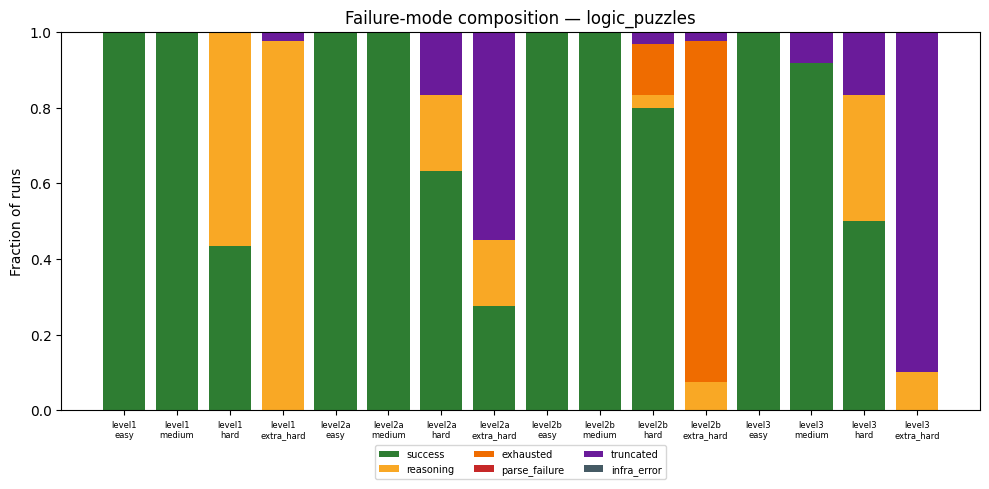

failure_mode,architecture,level,success,reasoning,exhausted,parse_failure,truncated,infra_error
0,level1,easy,1.000,0.000,0.000,0.0,0.000,0.0
1,level1,medium,1.000,0.000,0.000,0.0,0.000,0.0
2,level1,hard,0.925,0.050,0.000,0.0,0.025,0.0
3,level1,extra_hard,0.740,0.260,0.000,0.0,0.000,0.0
4,level2a,easy,0.975,0.025,0.000,0.0,0.000,0.0
5,level2a,medium,1.000,0.000,0.000,0.0,0.000,0.0
6,level2a,hard,0.875,0.100,0.000,0.0,0.025,0.0
7,level2a,extra_hard,0.520,0.320,0.000,0.0,0.160,0.0
8,level2b,easy,0.975,0.000,0.000,0.0,0.025,0.0
9,level2b,medium,0.975,0.000,0.025,0.0,0.000,0.0


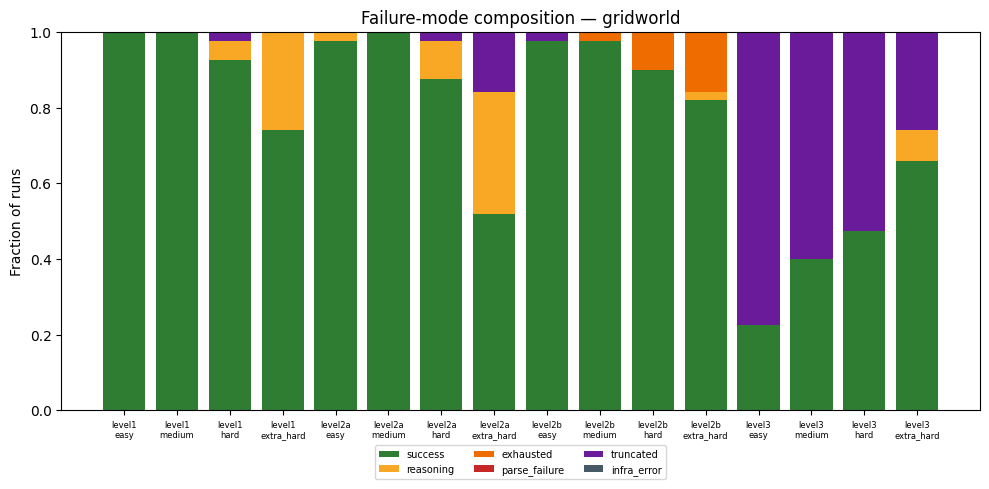

In [12]:
for dom in ["logic_puzzles", "gridworld"]:
    display(agg.failure_rate_table(df, dom))
    plots.plot_failure_stack(df, dom); plt.show()

**Interpretation.** The failure mix explains both the capability scores and the
dropped-run counts:

- **Logic `extra_hard` is a budget story, and each architecture fails its own way.**
  L1 is almost all `reasoning` (clean but wrong, 98%) — it runs out of competence;
  L2A loses 55% of runs to `truncated` — it runs out of tokens; L2B is 90%
  `exhausted` — the critic loops to the cap without converging.
- **L3 is truncation-bound.** L3 is dominated by `truncated` at the hard logic
  levels (90% at `extra_hard`) and across gridworld (52–78%): the 3-branch + critic
  loop simply hits the `max_tokens` ceiling. This is why L3's capability cells rest
  on few eligible runs and must be read alongside `l3_n` and the CIs.
- **The answer contract holds.** `parse_failure` is essentially absent everywhere,
  so failures are about reasoning and budget, not output formatting.